# Stock Deep Dive

Single-stock analysis notebook following the 11-section template from
`scratch_silver_schema_explorer.ipynb` ("Putting It All Together"). Reads silver +
gold tables directly from R2.

**How to parameterize:** edit the `Parameters` cell below (it is tagged `parameters`,
so this notebook is also [papermill](https://papermill.readthedocs.io/)-ready:
`papermill stock_deep_dive.ipynb out.ipynb -p TICKER NVDA`).

| Section | Source tables |
|---|---|
| 0. Peer set | `gold/dim_peer_sets` (algorithmic, overridable) |
| 1. Identity card | `gold/dim_company_enriched` |
| 2. Price vs. benchmarks | `silver/fact_daily_prices`, `silver/fact_splits` |
| 3. Dividend history | `silver/fact_dividends` |
| 4. Quarterly P&L | `gold/fact_fundamentals_wide` |
| 5. Balance sheet health | `gold/fact_fundamentals_wide` |
| 6. Cash flow quality | `gold/fact_fundamentals_wide` |
| 7. EPS beats/misses | `silver/fact_earnings` |
| 8. Earnings call sentiment | `gold/fact_transcript_sentiment` |
| 9. Insider signal log | `silver/fact_insider_transactions`, `gold/fact_insider_signals` |
| 10. Institutional snapshot | `silver/fact_institutional_holdings`, `silver/dim_institutional_summary`, `gold/fact_institutional_concentration` |
| 11. News sentiment trend | `gold/fact_sentiment_daily`, `silver/fact_news_articles` |


## 0. Parameters

In [1]:
# -- Parameters ---------------------------------------------------------------
TICKER = "AVGO"

# Peer set: None -> use gold/dim_peer_sets (algorithmic).
# Or hand-pick, e.g. ["NVDA", "AMD", "QCOM", "TXN"] to override the algorithm.
PEER_OVERRIDE = None

LOOKBACK_YEARS = 10             # sections 2-7
TRANSCRIPT_LOOKBACK_YEARS = 5   # section 8 (see note there on current coverage)
BENCHMARKS = ["SPY", "QQQ"]     # ETFs held in fact_daily_prices (adjusted_close)
MAX_PEERS = 5

NEWS_ROLL_DAYS = 30             # rolling window for news sentiment trend
MIN_NEWS_RELEVANCE = 0.30       # relevance_score cutoff for the headlines table
TOP_HOLDERS_N = 10              # institutional snapshot

## Setup

Same R2/DuckDB connection pattern as `scratch_silver_schema_explorer.ipynb`.

In [2]:
import os
import warnings
from datetime import date
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
from dotenv import load_dotenv

warnings.filterwarnings("ignore", message=".*Unverified HTTPS request.*")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
load_dotenv(PROJECT_ROOT / ".env")

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams.update({"figure.figsize": (12, 5), "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

BUCKET = os.environ["R2_BUCKET_NAME"]

def open_con() -> duckdb.DuckDBPyConnection:
    c = duckdb.connect()
    c.execute("INSTALL httpfs; LOAD httpfs;")
    c.execute(f"SET s3_endpoint = '{os.environ['R2_ACCOUNT_ID']}.r2.cloudflarestorage.com';")
    c.execute(f"SET s3_access_key_id = '{os.environ['R2_ACCESS_KEY_ID']}';")
    c.execute(f"SET s3_secret_access_key = '{os.environ['R2_SECRET_ACCESS_KEY']}';")
    c.execute("SET s3_region = 'auto';")
    c.execute("SET s3_url_style = 'path';")
    c.execute("SET enable_progress_bar = false;")
    return c

def silver(path: str) -> str:
    return f"read_parquet('s3://{BUCKET}/silver/{path}', union_by_name=true)"

def gold(path: str) -> str:
    return f"read_parquet('s3://{BUCKET}/gold/{path}', union_by_name=true)"

con = open_con()
q = lambda sql: con.execute(sql).df()

def sql_list(symbols) -> str:
    """Render a python list as a SQL IN-list. Symbols are validated first."""
    for s in symbols:
        assert s.replace(".", "").replace("-", "").isalnum(), f"suspicious symbol: {s}"
    return ", ".join(f"'{s}'" for s in symbols)

def fmt_usd(x, _pos=None):
    """Human money formatter for matplotlib axes."""
    for div, suf in [(1e12, "T"), (1e9, "B"), (1e6, "M"), (1e3, "K")]:
        if abs(x) >= div:
            return f"${x / div:,.1f}{suf}"
    return f"${x:,.0f}"

TODAY = date.today()
PX_START = TODAY.replace(year=TODAY.year - LOOKBACK_YEARS)
TRANSCRIPT_START_Q = f"{TODAY.year - TRANSCRIPT_LOOKBACK_YEARS}Q1"

_chk = q(f"SELECT symbol, name, sector, industry FROM {silver('dim_company/*.parquet')} WHERE symbol = '{TICKER}'")
assert not _chk.empty, f"{TICKER} not found in dim_company — is it in the universe?"
COMPANY_NAME = _chk.name.iloc[0]
print(f"DuckDB connected — bucket: {BUCKET}")
print(f"Deep dive: {TICKER} — {COMPANY_NAME} | {_chk.sector.iloc[0]} / {_chk.industry.iloc[0]}")
print(f"Price/fundamentals window: {PX_START} → {TODAY}")

DuckDB connected — bucket: equity-data-lake
Deep dive: AVGO — Broadcom Inc | TECHNOLOGY / SEMICONDUCTORS
Price/fundamentals window: 2016-07-02 → 2026-07-02


## 0b. Peer set — algorithmic, overridable

Peers come from `gold/dim_peer_sets` (rebuilt weekly by `transform_gold/build_peer_sets.py`):
same **industry** first (backfilled from sector when the industry is thin), candidates more
than 100× larger/smaller excluded, ranked by `0.6 × market-cap proximity + 0.4 × trailing-2y
daily-return correlation`.

Set `PEER_OVERRIDE = ["...", ...]` in the Parameters cell to bypass the algorithm entirely.
If the gold table is missing, an inline fallback (industry/sector + cap proximity, no
correlation term) is computed from `dim_company_enriched`.

In [3]:
if PEER_OVERRIDE:
    PEERS = [s.upper() for s in PEER_OVERRIDE][:MAX_PEERS]
    peer_df = pd.DataFrame({"peer_symbol": PEERS, "source": "manual override"})
else:
    peer_df = q(f"""
        SELECT peer_rank, peer_symbol, peer_name, industry_match,
               log_cap_ratio, return_corr_2y, score, as_of_date
        FROM {gold('dim_peer_sets/*.parquet')}
        WHERE symbol = '{TICKER}'
        ORDER BY peer_rank
        LIMIT {MAX_PEERS}
    """)
    if peer_df.empty:
        print("gold/dim_peer_sets has no rows for this symbol — falling back to inline "
              "industry/sector + market-cap proximity (run `python -m transform_gold.build_peer_sets`).")
        peer_df = q(f"""
            WITH me AS (
                SELECT sector, industry, COALESCE(market_cap_latest, market_cap) AS cap
                FROM {gold('dim_company_enriched/*.parquet')} WHERE symbol = '{TICKER}'
            )
            SELECT d.symbol AS peer_symbol, d.name AS peer_name,
                   (d.industry = me.industry) AS industry_match,
                   LOG10(COALESCE(d.market_cap_latest, d.market_cap) / me.cap) AS log_cap_ratio
            FROM {gold('dim_company_enriched/*.parquet')} d, me
            WHERE d.symbol <> '{TICKER}' AND d.asset_type = 'Stock'
              AND d.listing_status = 'active'
              AND COALESCE(d.market_cap_latest, d.market_cap) > 0
              AND (d.industry = me.industry OR d.sector = me.sector)
              AND ABS(LOG10(COALESCE(d.market_cap_latest, d.market_cap) / me.cap)) <= 2
            ORDER BY industry_match DESC, ABS(log_cap_ratio)
            LIMIT {MAX_PEERS}
        """)
    PEERS = peer_df.peer_symbol.tolist()

print(f"Peer set for {TICKER}: {PEERS}")
peer_df

Peer set for AVGO: ['MU', 'NVDA', 'AMD', 'INTC', 'ADI']


,peer_rank,peer_symbol,peer_name,industry_match,log_cap_ratio,return_corr_2y,score,as_of_date
0,1,MU,Micron Technology Inc,True,-0.1441,0.5550,0.7788,2026-07-03
1,2,NVDA,NVIDIA Corp,True,0.4232,0.6528,0.7342,2026-07-03
2,3,AMD,Advanced Micro Devices Inc,True,-0.2908,0.4938,0.7103,2026-07-03
3,4,INTC,Intel Corp,True,-0.4142,0.3302,0.6078,2026-07-03
4,5,ADI,Analog Devices Inc,True,-0.9757,0.4719,0.4960,2026-07-03


---
## 1. Identity card

`dim_company_enriched` row — sector, industry, IPO date, market cap, shares outstanding — plus a side-by-side with the peer set.

In [4]:
ident_cols = """symbol, name, exchange, sector, industry, country, ipo_date, fiscal_year_end,
    market_cap_latest, shares_outstanding, latest_close, as_of_date,
    total_revenue_ttm, net_income_ttm, free_cash_flow_ttm, reported_eps_ttm,
    gross_margin, operating_margin, net_margin, roe, roic, debt_to_equity,
    revenue_growth_yoy, eps_growth_yoy, eps_cagr_5y,
    price_return_1y, price_return_3y, price_return_5y"""

identity = q(f"""
    SELECT {ident_cols}
    FROM {gold('dim_company_enriched/*.parquet')}
    WHERE symbol IN ({sql_list([TICKER] + PEERS)})
""").set_index("symbol").reindex([TICKER] + PEERS)

# Full identity card for the subject ticker
display(identity.loc[[TICKER]].T.rename(columns={TICKER: f"{TICKER} — identity card"}))

# Compact comparison vs. peers
identity[["name", "industry", "market_cap_latest", "total_revenue_ttm", "net_margin",
          "roic", "revenue_growth_yoy", "price_return_1y"]]

symbol,AVGO — identity card
name,Broadcom Inc
exchange,NASDAQ
sector,TECHNOLOGY
industry,SEMICONDUCTORS
country,USA
ipo_date,2009-08-06 00:00:00
fiscal_year_end,October
market_cap_latest,"1,841,909,000,000.0000"
shares_outstanding,"4,876,000,000.0000"
latest_close,377.7500


,name,industry,market_cap_latest,total_revenue_ttm,net_margin,roic,revenue_growth_yoy,price_return_1y
symbol,,,,,,,,
AVGO,Broadcom Inc,SEMICONDUCTORS,"1,841,909,000,000.0000","75,465,000,000.0000",0.4196,0.0723,0.4787,0.3805
MU,Micron Technology Inc,SEMICONDUCTORS,"1,321,662,050,000.0000","90,274,000,000.0000",0.6813,0.3212,3.4572,8.3882
NVDA,NVIDIA Corp,SEMICONDUCTORS,"4,880,395,190,000.0000","253,491,000,000.0000",0.7146,0.2638,0.8523,0.2681
AMD,Advanced Micro Devices Inc,SEMICONDUCTORS,"942,816,930,000.0000","37,454,000,000.0000",0.1349,0.0221,0.3785,3.0938
INTC,Intel Corp,SEMICONDUCTORS,"709,739,290,000.0000","53,763,000,000.0000",-0.2746,-0.0203,0.0718,5.2335
ADI,Analog Devices Inc,SEMICONDUCTORS,"194,795,203,860.0000","12,740,193,000.0000",0.3246,0.0337,0.3725,0.6911


---
## 2. Price chart with benchmarks

Normalized total-return-ish index (base 100, `adjusted_close`) vs. benchmark ETFs, annotated
with split dates from `fact_splits`. Benchmarks are pulled from `fact_daily_prices` (SPY/QQQ
are in the universe as ETFs); `fact_index_prices` carries raw index levels (SPX, COMP, ...)
but no adjusted close, so ETFs make the cleaner comparison line. A second panel shows the
same normalization against the peer set.

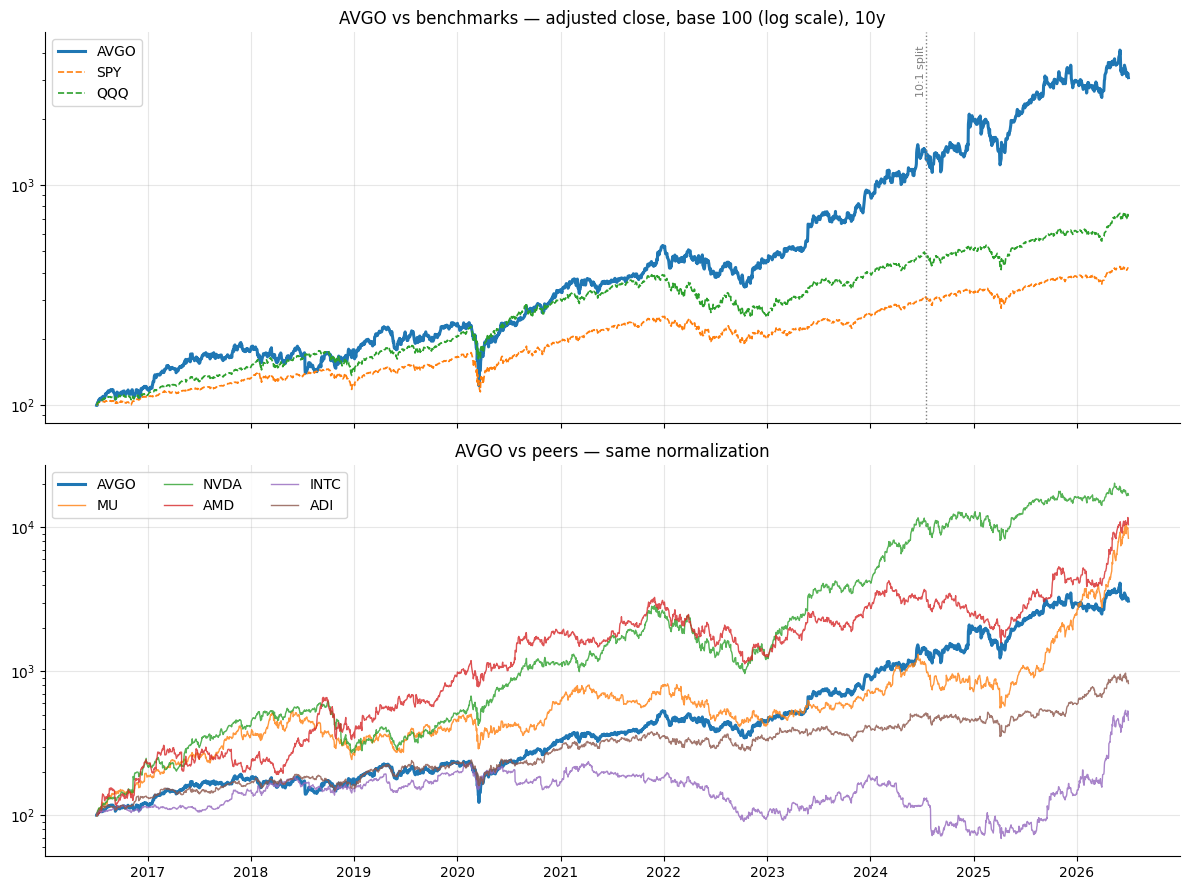

In [5]:
px = q(f"""
    SELECT symbol, trade_date, adjusted_close
    FROM {silver('fact_daily_prices/**/*.parquet')}
    WHERE symbol IN ({sql_list([TICKER] + BENCHMARKS + PEERS)})
      AND trade_date >= DATE '{PX_START}'
    ORDER BY trade_date
""")
px_wide = px.pivot_table(index="trade_date", columns="symbol", values="adjusted_close")
# Base-100 on the first date where the subject ticker trades
px_wide = px_wide[px_wide[TICKER].notna()]
px_idx = px_wide / px_wide.iloc[0] * 100

splits = q(f"""
    SELECT effective_date, split_ratio FROM {silver('fact_splits/*.parquet')}
    WHERE symbol = '{TICKER}' AND effective_date >= DATE '{PX_START}'
    ORDER BY effective_date
""")

fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)
ax = axes[0]
ax.plot(px_idx.index, px_idx[TICKER], lw=2.2, color="C0", label=TICKER)
for i, b in enumerate(BENCHMARKS):
    if b in px_idx:
        ax.plot(px_idx.index, px_idx[b], lw=1.2, ls="--", color=f"C{i+1}", label=b)
for _, s in splits.iterrows():
    ax.axvline(pd.Timestamp(s.effective_date), color="grey", ls=":", lw=1)
    ax.annotate(f"{s.split_ratio:g}:1 split", xy=(pd.Timestamp(s.effective_date), ax.get_ylim()[1]),
                rotation=90, va="top", ha="right", fontsize=8, color="grey")
ax.set_yscale("log")
ax.set_title(f"{TICKER} vs benchmarks — adjusted close, base 100 (log scale), {LOOKBACK_YEARS}y")
ax.legend(loc="upper left")

ax = axes[1]
ax.plot(px_idx.index, px_idx[TICKER], lw=2.2, color="C0", label=TICKER)
for i, p in enumerate(PEERS):
    if p in px_idx:
        series = px_idx[p].dropna()
        ax.plot(series.index, series, lw=1.0, alpha=0.8, color=f"C{i+1}", label=p)
ax.set_yscale("log")
ax.set_title(f"{TICKER} vs peers — same normalization")
ax.legend(loc="upper left", ncols=3)
plt.tight_layout()
plt.show()

---
## 3. Dividend history

Dividend per share by ex-date (bars) and trailing-12-month yield on the then-current price (line).

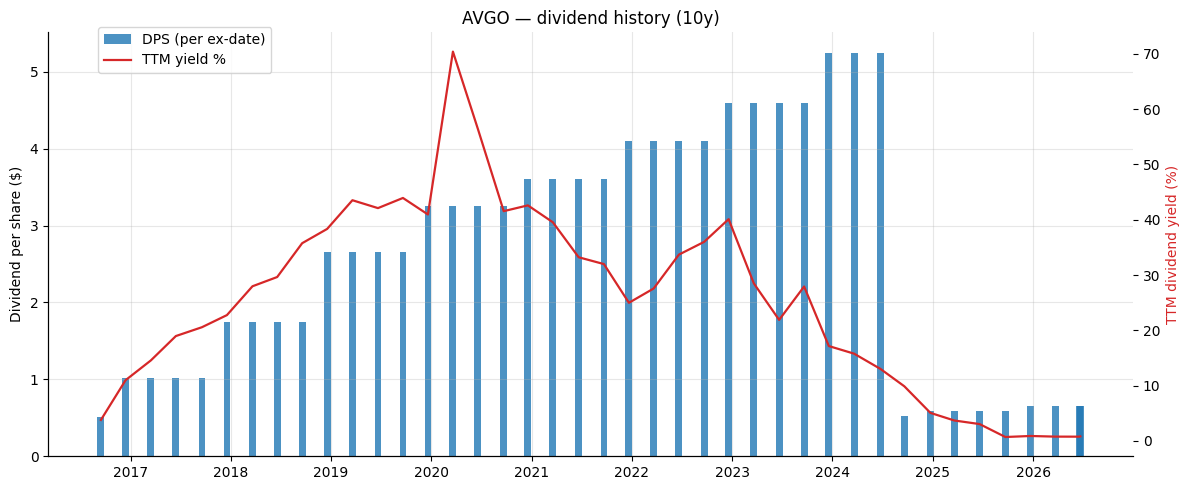

Trailing-4Q DPS: 2.6


In [6]:
divs = q(f"""
    SELECT ex_date, amount FROM {silver('fact_dividends/*.parquet')}
    WHERE symbol = '{TICKER}' AND ex_date >= DATE '{PX_START}'
    ORDER BY ex_date
""")

if divs.empty:
    print(f"{TICKER} paid no dividends in the last {LOOKBACK_YEARS} years.")
else:
    divs["ex_date"] = pd.to_datetime(divs.ex_date)
    divs = divs.set_index("ex_date")
    ttm_dps = divs.amount.rolling("365D").sum()

    close = px_wide[TICKER].copy()
    close.index = pd.to_datetime(close.index)
    ttm_yield = (ttm_dps / close.reindex(ttm_dps.index, method="ffill")) * 100

    fig, ax = plt.subplots()
    ax.bar(divs.index, divs.amount, width=25, color="C0", alpha=0.8, label="DPS (per ex-date)")
    ax.set_ylabel("Dividend per share ($)")
    ax2 = ax.twinx()
    ax2.plot(ttm_yield.index, ttm_yield, color="C3", lw=1.6, label="TTM yield %")
    ax2.set_ylabel("TTM dividend yield (%)", color="C3")
    ax2.grid(False)
    ax.set_title(f"{TICKER} — dividend history ({LOOKBACK_YEARS}y)")
    fig.legend(loc="upper left", bbox_to_anchor=(0.08, 0.95))
    plt.tight_layout(); plt.show()

    print("Trailing-4Q DPS:", round(divs.amount.tail(4).sum(), 4))

---
## 4. Quarterly P&L trend

Both renderings requested for evaluation:
1. **Line chart** — 10y quarterly revenue / gross profit / operating income / net income with margins on a secondary axis (good for *trend*).
2. **Waterfall** — latest quarter's decomposition from revenue down to net income (good for *structure*, single period).

40 quarterly periods, 2016-07-31 → 2026-04-30


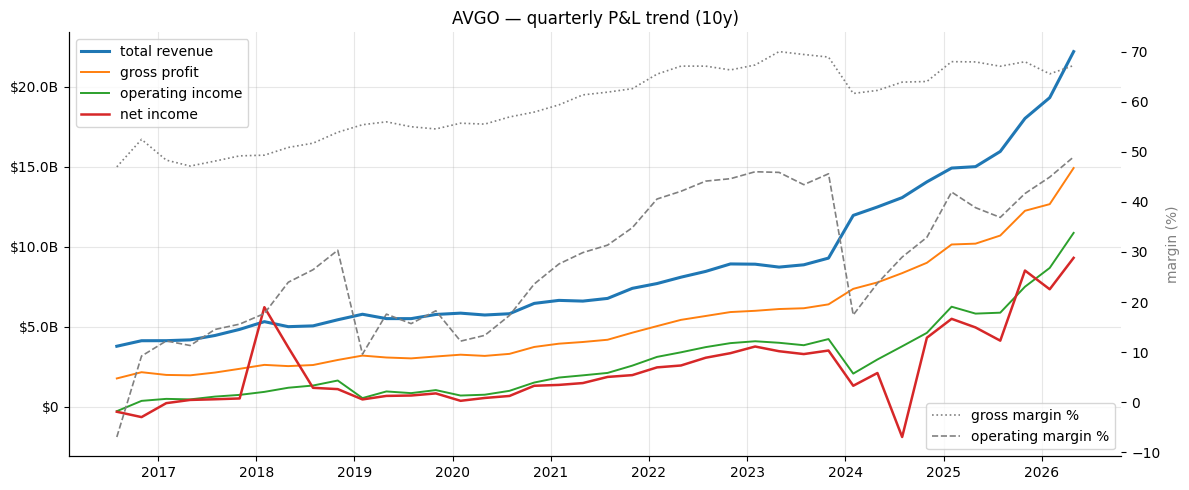

In [7]:
fw = q(f"""
    SELECT fiscal_date_ending, total_revenue, gross_profit, operating_income, net_income,
           r_and_d, sga, interest_expense, income_tax,
           gross_margin, operating_margin, net_margin,
           current_assets, current_liabilities, long_term_debt, short_term_debt,
           cash_and_equivalents, short_term_investments, total_equity, debt_to_equity, net_debt,
           operating_cashflow, capex, free_cash_flow, cash_conversion,
           total_revenue_ttm, net_income_ttm, free_cash_flow_ttm, operating_cashflow_ttm, capex_ttm
    FROM {gold('fact_fundamentals_wide/*.parquet')}
    WHERE symbol = '{TICKER}' AND period_type = 'quarterly'
      AND fiscal_date_ending >= DATE '{PX_START}'
    ORDER BY fiscal_date_ending
""")
fw["fiscal_date_ending"] = pd.to_datetime(fw.fiscal_date_ending)
print(f"{len(fw)} quarterly periods, {fw.fiscal_date_ending.min():%Y-%m-%d} → {fw.fiscal_date_ending.max():%Y-%m-%d}")

fig, ax = plt.subplots()
for col, lw in [("total_revenue", 2.2), ("gross_profit", 1.4), ("operating_income", 1.4), ("net_income", 1.8)]:
    ax.plot(fw.fiscal_date_ending, fw[col], lw=lw, label=col.replace("_", " "))
ax.yaxis.set_major_formatter(mtick.FuncFormatter(fmt_usd))
ax.set_title(f"{TICKER} — quarterly P&L trend ({LOOKBACK_YEARS}y)")
ax.legend(loc="upper left")
ax2 = ax.twinx()
ax2.plot(fw.fiscal_date_ending, fw.gross_margin * 100, color="grey", ls=":", lw=1.2, label="gross margin %")
ax2.plot(fw.fiscal_date_ending, fw.operating_margin * 100, color="grey", ls="--", lw=1.2, label="operating margin %")
ax2.set_ylabel("margin (%)", color="grey")
ax2.grid(False)
ax2.legend(loc="lower right")
plt.tight_layout(); plt.show()

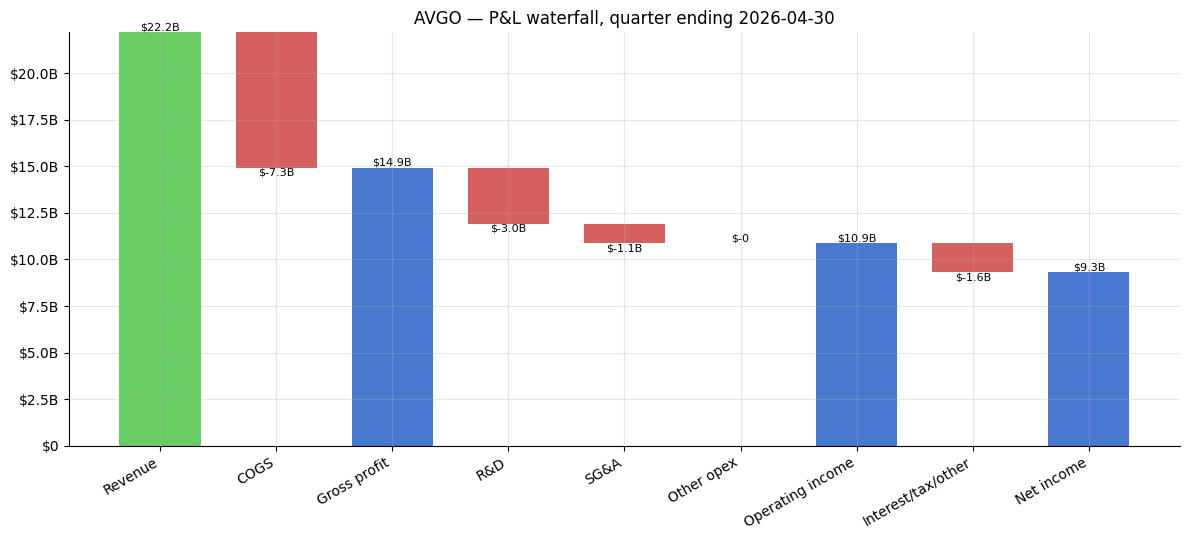

In [8]:
def waterfall(ax, labels, deltas, is_total):
    """Simple matplotlib waterfall. deltas: signed contributions; is_total: bars that
    restate the running total (plotted from zero)."""
    running, bottoms, heights = 0.0, [], []
    for d, t in zip(deltas, is_total):
        if t:
            bottoms.append(0); heights.append(running)
        else:
            bottoms.append(running); heights.append(d); running += d
    colors = ["#4878CF" if t else ("#6ACC65" if h >= 0 else "#D65F5F")
              for h, t in zip(heights, is_total)]
    ax.bar(range(len(labels)), heights, bottom=bottoms, color=colors, width=0.7)
    for i, (b, h) in enumerate(zip(bottoms, heights)):
        ax.annotate(fmt_usd(h), (i, b + h), ha="center",
                    va="bottom" if h >= 0 else "top", fontsize=8)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(fmt_usd))

latest = fw.dropna(subset=["total_revenue", "gross_profit", "operating_income", "net_income"]).iloc[-1]
rev, gp, oi, ni = latest.total_revenue, latest.gross_profit, latest.operating_income, latest.net_income
rnd  = latest.r_and_d if pd.notna(latest.r_and_d) else 0.0
sga  = latest.sga if pd.notna(latest.sga) else 0.0
other_opex = (gp - oi) - rnd - sga          # residual operating costs
below_line = ni - oi                        # interest, tax, other (net)

labels = ["Revenue", "COGS", "Gross profit", "R&D", "SG&A", "Other opex",
          "Operating income", "Interest/tax/other", "Net income"]
deltas = [rev, -(rev - gp), None, -rnd, -sga, -other_opex, None, below_line, None]
is_total = [False, False, True, False, False, False, True, False, True]
deltas = [0 if d is None else d for d in deltas]

fig, ax = plt.subplots(figsize=(12, 5.5))
waterfall(ax, labels, deltas, is_total)
ax.set_title(f"{TICKER} — P&L waterfall, quarter ending {latest.fiscal_date_ending:%Y-%m-%d}")
plt.tight_layout(); plt.show()

> **Evaluating the two:** the waterfall only shows one quarter, so it answers "where does
> a dollar of revenue go" while the line chart answers "how is that changing." If you keep
> only one, the line chart carries more information for a deep dive; the waterfall earns its
> keep as a companion when margin structure shifted (e.g. an acquisition quarter).

---
## 5. Balance sheet health

Current ratio, debt-to-equity, cash position, and net debt over time.

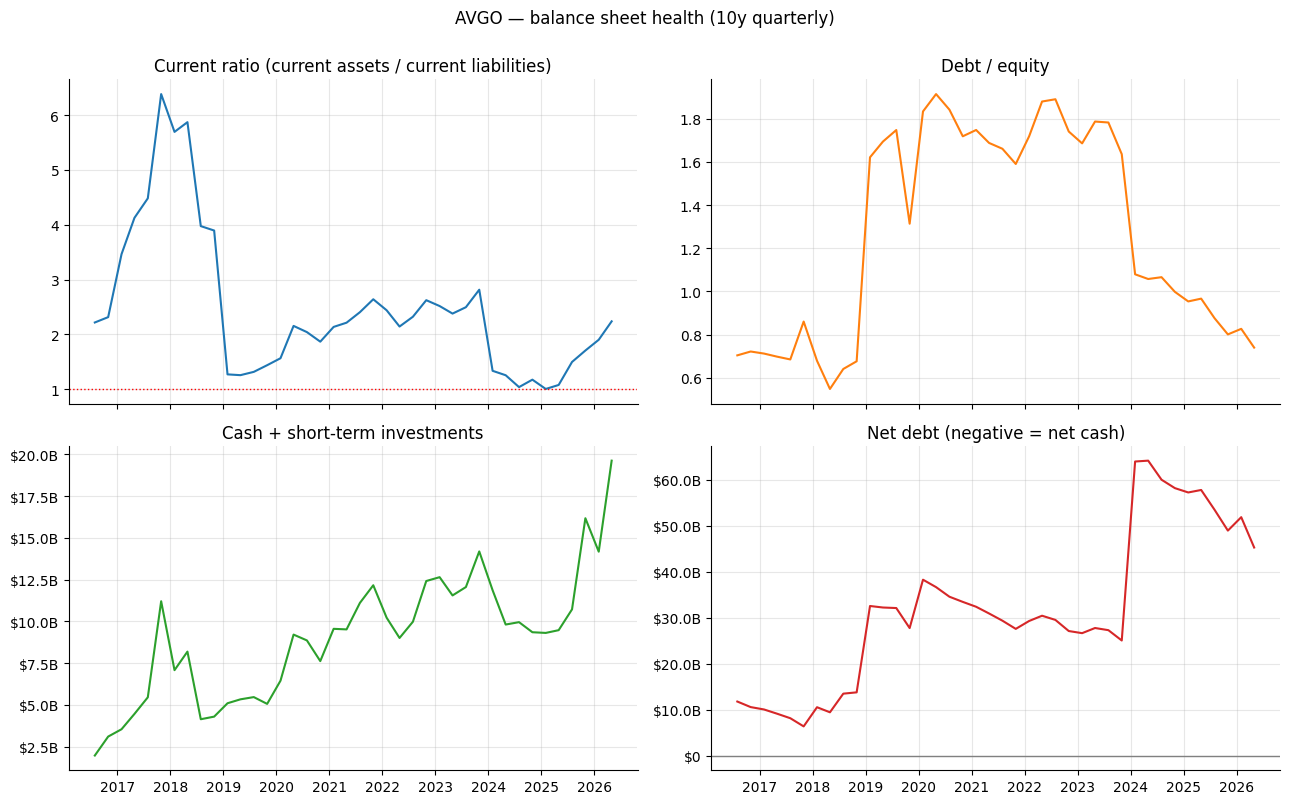

In [9]:
bs = fw.copy()
bs["current_ratio"] = bs.current_assets / bs.current_liabilities
bs["cash_sti"] = bs.cash_and_equivalents.fillna(0) + bs.short_term_investments.fillna(0)

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
axes[0, 0].plot(bs.fiscal_date_ending, bs.current_ratio, color="C0")
axes[0, 0].axhline(1.0, color="red", ls=":", lw=1)
axes[0, 0].set_title("Current ratio (current assets / current liabilities)")

axes[0, 1].plot(bs.fiscal_date_ending, bs.debt_to_equity, color="C1")
axes[0, 1].set_title("Debt / equity")

axes[1, 0].plot(bs.fiscal_date_ending, bs.cash_sti, color="C2")
axes[1, 0].yaxis.set_major_formatter(mtick.FuncFormatter(fmt_usd))
axes[1, 0].set_title("Cash + short-term investments")

axes[1, 1].plot(bs.fiscal_date_ending, bs.net_debt, color="C3")
axes[1, 1].axhline(0, color="grey", lw=1)
axes[1, 1].yaxis.set_major_formatter(mtick.FuncFormatter(fmt_usd))
axes[1, 1].set_title("Net debt (negative = net cash)")

fig.suptitle(f"{TICKER} — balance sheet health ({LOOKBACK_YEARS}y quarterly)", y=1.0)
plt.tight_layout(); plt.show()

---
## 6. Cash flow quality

Trailing-twelve-month FCF vs. net income (FCF persistently below net income is the classic
earnings-quality red flag), plus capex as % of revenue. TTM columns smooth the seasonality
that makes single quarters noisy.

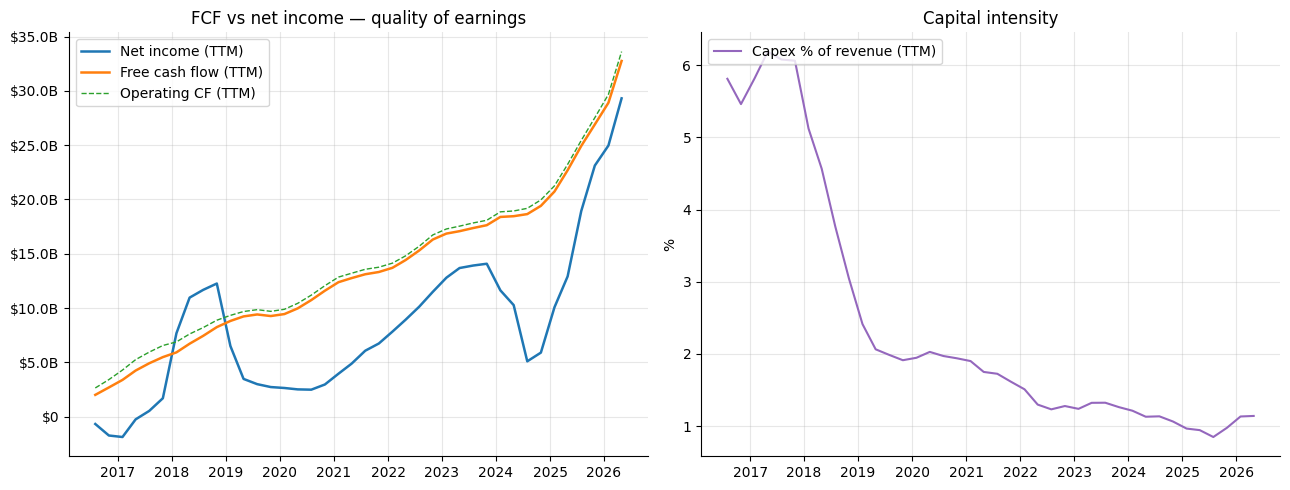

,fiscal_date_ending,net_income_ttm,free_cash_flow_ttm,fcf_to_ni_ttm,capex_pct_rev_ttm
36,2025-07-31,"18,932,000,000.0000","24,930,000,000.0000",1.3168,0.8477
37,2025-10-31,"23,126,000,000.0000","26,914,000,000.0000",1.1638,0.9752
38,2026-01-31,"24,972,000,000.0000","28,911,000,000.0000",1.1577,1.1321
39,2026-04-30,"29,317,000,000.0000","32,762,000,000.0000",1.1175,1.1396


In [10]:
cf = fw.dropna(subset=["total_revenue_ttm"]).copy()
cf["capex_pct_rev_ttm"] = cf.capex_ttm.abs() / cf.total_revenue_ttm * 100
cf["fcf_to_ni_ttm"] = cf.free_cash_flow_ttm / cf.net_income_ttm

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
ax.plot(cf.fiscal_date_ending, cf.net_income_ttm, lw=1.8, label="Net income (TTM)")
ax.plot(cf.fiscal_date_ending, cf.free_cash_flow_ttm, lw=1.8, label="Free cash flow (TTM)")
ax.plot(cf.fiscal_date_ending, cf.operating_cashflow_ttm, lw=1.0, ls="--", label="Operating CF (TTM)")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(fmt_usd))
ax.set_title("FCF vs net income — quality of earnings")
ax.legend(loc="upper left")

ax = axes[1]
ax.plot(cf.fiscal_date_ending, cf.capex_pct_rev_ttm, color="C4", label="Capex % of revenue (TTM)")
ax.set_ylabel("%")
ax.set_title("Capital intensity")
ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

cf.tail(4)[["fiscal_date_ending", "net_income_ttm", "free_cash_flow_ttm", "fcf_to_ni_ttm", "capex_pct_rev_ttm"]]

---
## 7. EPS beats & misses

Quarterly EPS surprise % from `fact_earnings`. Green = beat, red = miss.

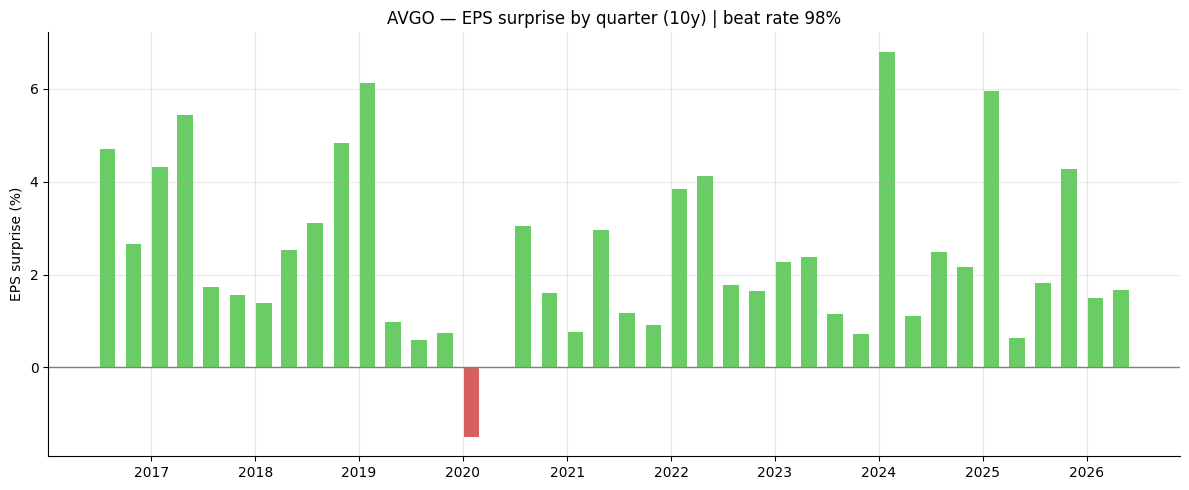

,report_date,reported_eps,estimated_eps,surprise,surprise_pct
fiscal_date_ending,,,,,
2024-07-31,2024-09-05,1.2400,1.2100,0.0300,2.4793
2024-10-31,2024-12-12,1.4200,1.3900,0.0300,2.1583
2025-01-31,2025-03-06,1.6000,1.5100,0.0900,5.9603
2025-04-30,2025-06-05,1.5800,1.5700,0.0100,0.6369
2025-07-31,2025-09-04,1.6900,1.6600,0.0300,1.8072
2025-10-31,2025-12-11,1.9500,1.8700,0.0800,4.2781
2026-01-31,2026-03-04,2.0500,2.0200,0.0300,1.4851
2026-04-30,2026-06-03,2.4400,2.4000,0.0400,1.6667


In [11]:
eps = q(f"""
    SELECT fiscal_date_ending, report_date, reported_eps, estimated_eps, surprise, surprise_pct
    FROM {silver('fact_earnings/*.parquet')}
    WHERE symbol = '{TICKER}' AND period_type = 'quarterly'
      AND fiscal_date_ending >= DATE '{PX_START}'
      AND reported_eps IS NOT NULL
    ORDER BY fiscal_date_ending
""")
eps["fiscal_date_ending"] = pd.to_datetime(eps.fiscal_date_ending)

plot_df = eps.dropna(subset=["surprise_pct"])
fig, ax = plt.subplots()
ax.bar(plot_df.fiscal_date_ending, plot_df.surprise_pct, width=55,
       color=np.where(plot_df.surprise_pct >= 0, "#6ACC65", "#D65F5F"))
ax.axhline(0, color="grey", lw=1)
ax.set_ylabel("EPS surprise (%)")
beat_rate = (plot_df.surprise_pct >= 0).mean() * 100
ax.set_title(f"{TICKER} — EPS surprise by quarter ({LOOKBACK_YEARS}y) | beat rate {beat_rate:.0f}%")
plt.tight_layout(); plt.show()

eps.tail(8).set_index("fiscal_date_ending")

---
## 8. Earnings call sentiment

Per-call average sentiment from `gold/fact_transcript_sentiment`, split management vs.
analyst (built from `fact_transcript_turns` — operator turns excluded). The
management-minus-analyst **spread** is the tell: management is structurally sunny, so watch
for spread compression (management losing conviction) or analyst sentiment diverging.

> **Coverage note:** the transcript backfill (`transcripts_backfill.yml`, target ~10y) has
> not fully run yet — silver currently holds roughly one quarter per symbol. The query below
> asks for 5 years and will fill in automatically as the backfill lands.

1 call(s) available for AVGO since 2021Q1.


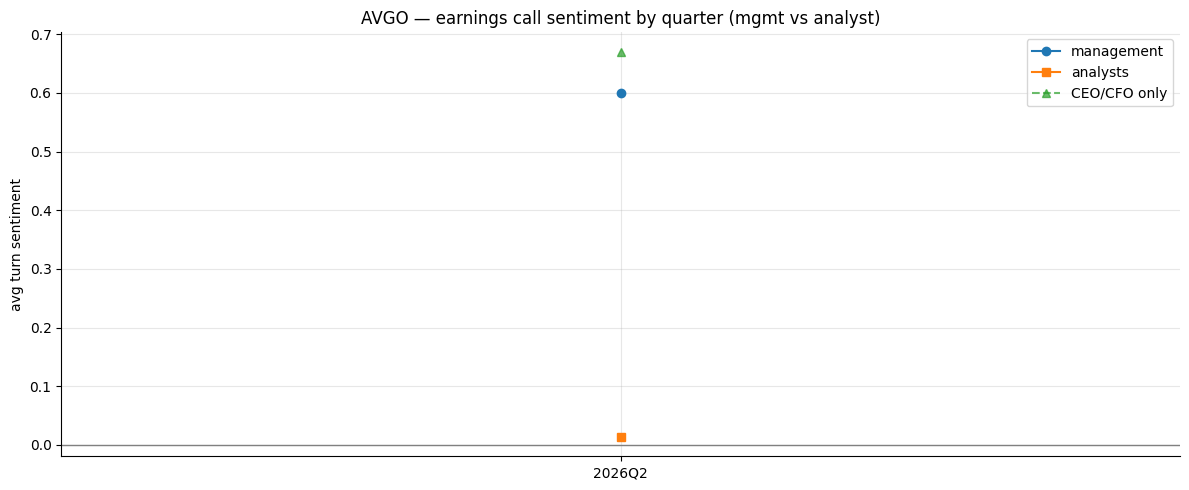

,quarter,call_date,mgmt_turns,analyst_turns,mgmt_avg_sentiment,analyst_avg_sentiment,ceo_cfo_avg_sentiment,mgmt_wtd_sentiment,analyst_wtd_sentiment,mgmt_analyst_spread
0,2026Q2,2026-06-03,19,15,0.6000,0.0133,0.6706,0.6768,0.0136,0.5867


,symbol,quarter,mgmt_avg_sentiment,analyst_avg_sentiment,mgmt_analyst_spread
0,ADI,2026Q2,0.3458,0.0000,0.3458
1,MU,2026Q2,0.5167,0.0706,0.4461
2,NVDA,2026Q2,0.7500,0.3000,0.4500
3,AVGO,2026Q2,0.6000,0.0133,0.5867
4,AMD,2026Q1,0.7037,-0.0000,0.7037


In [12]:
ts = q(f"""
    SELECT quarter, call_date, mgmt_turns, analyst_turns,
           mgmt_avg_sentiment, analyst_avg_sentiment, ceo_cfo_avg_sentiment,
           mgmt_wtd_sentiment, analyst_wtd_sentiment, mgmt_analyst_spread
    FROM {gold('fact_transcript_sentiment/*.parquet')}
    WHERE symbol = '{TICKER}' AND quarter >= '{TRANSCRIPT_START_Q}'
    ORDER BY quarter
""")

if ts.empty:
    print(f"No transcript data for {TICKER} yet — check silver/fact_transcript_turns coverage "
          "or run the transcripts backfill workflow.")
else:
    n = len(ts)
    print(f"{n} call(s) available for {TICKER} since {TRANSCRIPT_START_Q}.")
    fig, ax = plt.subplots()
    ax.plot(ts.quarter, ts.mgmt_avg_sentiment, "o-", label="management", color="C0")
    ax.plot(ts.quarter, ts.analyst_avg_sentiment, "s-", label="analysts", color="C1")
    ax.plot(ts.quarter, ts.ceo_cfo_avg_sentiment, "^--", label="CEO/CFO only", color="C2", alpha=0.7)
    ax.axhline(0, color="grey", lw=1)
    ax.set_ylabel("avg turn sentiment")
    ax.set_title(f"{TICKER} — earnings call sentiment by quarter (mgmt vs analyst)")
    ax.legend()
    plt.tight_layout(); plt.show()
    display(ts)

# Peer comparison on the most recent call each peer has
peer_ts = q(f"""
    SELECT symbol, quarter, mgmt_avg_sentiment, analyst_avg_sentiment, mgmt_analyst_spread
    FROM {gold('fact_transcript_sentiment/*.parquet')}
    WHERE symbol IN ({sql_list([TICKER] + PEERS)})
    QUALIFY ROW_NUMBER() OVER (PARTITION BY symbol ORDER BY quarter DESC) = 1
    ORDER BY mgmt_analyst_spread
""")
peer_ts

---
## 9. Insider signal log

The high-signal Form 4 events flagged in the scratch notebook:

| Signal | Implementation |
|---|---|
| **Cluster buys** | ≥3 distinct executives with open-market buys inside a 30-day window (event-level here; `gold/fact_insider_signals.cluster_buy_flag_30d` gives the rolling daily flag) |
| **CEO/CFO open-market purchase** | `acquisition_or_disposal = 'A'` + C-suite title + `security_type = 'Common Stock'` + `share_price > 0` (excludes RSU vests/grants) |
| **Large disposals** | `'D'` events ranked by `shares × share_price` dollar value |
| **Timing vs. price** | buys/sells scattered on the adjusted-close chart |


In [13]:
ins = q(f"""
    SELECT transaction_date, executive, executive_title, security_type,
           acquisition_or_disposal, shares, share_price,
           shares * share_price AS dollar_value
    FROM {silver('fact_insider_transactions/*.parquet')}
    WHERE symbol = '{TICKER}'
    ORDER BY transaction_date
""")

if ins.empty:
    print(f"No insider transactions on record for {TICKER}.")
else:
    ins["transaction_date"] = pd.to_datetime(ins.transaction_date)
    ceo_cfo = ins.executive_title.str.contains(
        r"chief executive|chief financial|\bCEO\b|\bCFO\b", case=False, na=False)
    open_mkt = ins.security_type.str.contains("Common", case=False, na=False) & (ins.share_price > 0)

    ins["signal"] = ""
    ins.loc[(ins.acquisition_or_disposal == "A") & open_mkt & ceo_cfo, "signal"] = "CEO/CFO open-market BUY"
    # cluster buys: distinct buyers of common stock within a rolling 30d window
    buys = ins[(ins.acquisition_or_disposal == "A") & open_mkt]
    for d in buys.transaction_date.unique():
        window = buys[(buys.transaction_date >= d - pd.Timedelta(days=30)) & (buys.transaction_date <= d)]
        if window.executive.nunique() >= 3:
            ins.loc[(ins.transaction_date == d) & (ins.acquisition_or_disposal == "A") & open_mkt,
                    "signal"] = (ins.signal + " +cluster buy").str.strip(" +")
    # large disposals: top-quartile dollar value among D events
    d_mask = (ins.acquisition_or_disposal == "D") & (ins.dollar_value > 0)
    if d_mask.any():
        thresh = ins.loc[d_mask, "dollar_value"].quantile(0.75)
        ins.loc[d_mask & (ins.dollar_value >= thresh), "signal"] = "large disposal"

    print(f"{len(ins)} transactions | A: {(ins.acquisition_or_disposal == 'A').sum()}, "
          f"D: {(ins.acquisition_or_disposal == 'D').sum()}")
    display(ins.sort_values("dollar_value", ascending=False).head(20)
               .style.format({"shares": "{:,.0f}", "share_price": "{:,.2f}", "dollar_value": "${:,.0f}"}))

42 transactions | A: 2, D: 40


,transaction_date,executive,executive_title,security_type,acquisition_or_disposal,shares,share_price,dollar_value,signal
40,2026-06-24 00:00:00,"SAMUELI, HENRY",Director,"Common Stock, $0.001 par value",D,"53,722",385.57,"$20,713,592",large disposal
26,2026-06-24 00:00:00,"SAMUELI, HENRY",Director,"Common Stock, $0.001 par value",D,"49,805",380.57,"$18,954,289",large disposal
39,2026-06-24 00:00:00,"SAMUELI, HENRY",Director,"Common Stock, $0.001 par value",D,"48,996",380.57,"$18,646,408",large disposal
30,2026-06-24 00:00:00,"SAMUELI, HENRY",Director,"Common Stock, $0.001 par value",D,"47,510",385.61,"$18,320,331",large disposal
19,2026-06-24 00:00:00,"SAMUELI, HENRY",Director,"Common Stock, $0.001 par value",D,"43,302",384.58,"$16,653,083",large disposal
32,2026-06-24 00:00:00,"SAMUELI, HENRY",Director,"Common Stock, $0.001 par value",D,"41,290",384.63,"$15,881,373",large disposal
36,2026-06-24 00:00:00,"SAMUELI, HENRY",Director,"Common Stock, $0.001 par value",D,"36,661",381.68,"$13,992,770",large disposal
22,2026-06-24 00:00:00,"SAMUELI, HENRY",Director,"Common Stock, $0.001 par value",D,"36,188",383.69,"$13,884,974",large disposal
27,2026-06-24 00:00:00,"SAMUELI, HENRY",Director,"Common Stock, $0.001 par value",D,"34,517",381.67,"$13,174,103",large disposal
29,2026-06-24 00:00:00,"SAMUELI, HENRY",Director,"Common Stock, $0.001 par value",D,"32,950",383.69,"$12,642,586",


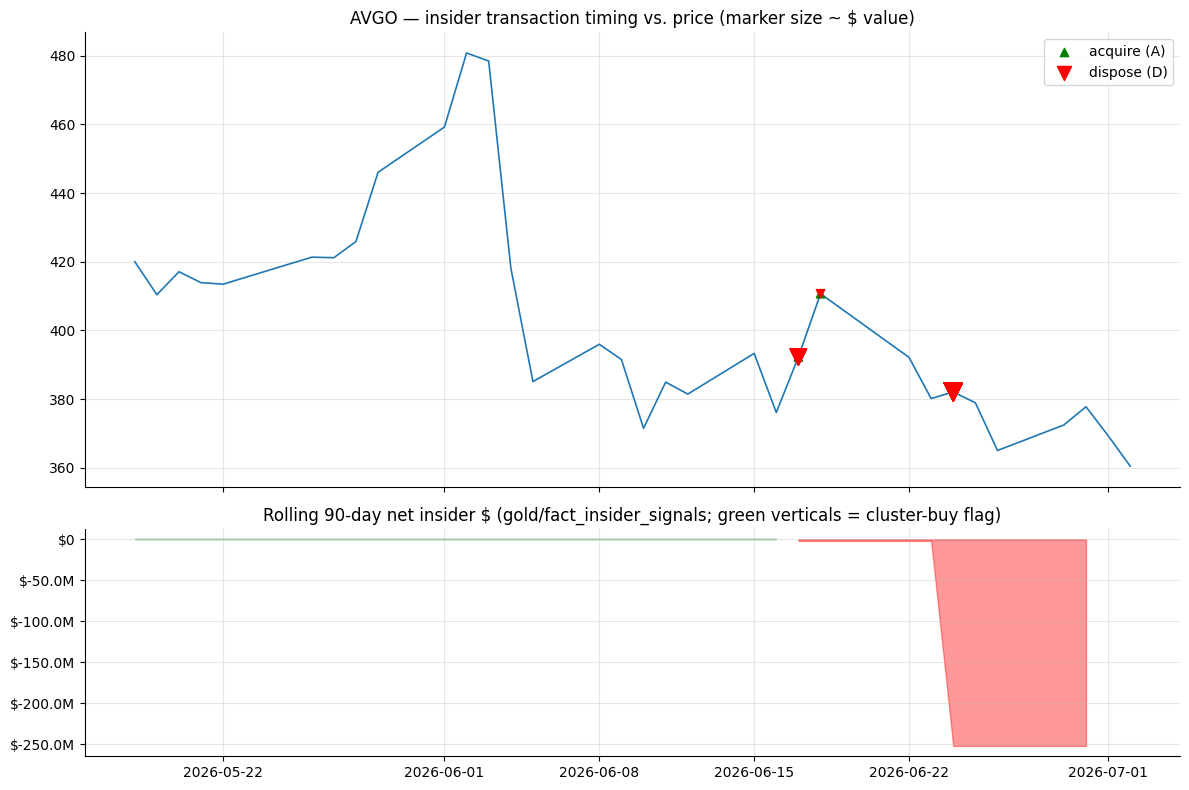

In [14]:
if not ins.empty:
    # Timing vs. price: markers placed on the adjusted close so pre-split prices line up
    close3y = px_wide[TICKER].dropna()
    close3y.index = pd.to_datetime(close3y.index)
    start_ins = max(ins.transaction_date.min() - pd.Timedelta(days=30), close3y.index.min())
    close3y = close3y[close3y.index >= start_ins]

    def px_at(dts):
        return close3y.reindex(pd.to_datetime(dts), method="ffill").values

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True,
                             gridspec_kw={"height_ratios": [2, 1]})
    ax = axes[0]
    ax.plot(close3y.index, close3y, color="C0", lw=1.2)
    a_ev = ins[ins.acquisition_or_disposal == "A"]
    d_ev = ins[ins.acquisition_or_disposal == "D"]
    ax.scatter(a_ev.transaction_date, px_at(a_ev.transaction_date), marker="^", s=36 + 8*np.log1p(a_ev.dollar_value.fillna(0)),
               color="green", zorder=3, label="acquire (A)")
    ax.scatter(d_ev.transaction_date, px_at(d_ev.transaction_date), marker="v", s=36 + 8*np.log1p(d_ev.dollar_value.fillna(0)),
               color="red", zorder=3, label="dispose (D)")
    ax.set_title(f"{TICKER} — insider transaction timing vs. price (marker size ~ $ value)")
    ax.legend()

    # Rolling net insider USD from gold
    sig = q(f"""
        SELECT as_of_date, net_insider_usd_90d, cluster_buy_flag_30d
        FROM {gold('fact_insider_signals/*.parquet')}
        WHERE symbol = '{TICKER}' ORDER BY as_of_date
    """)
    ax = axes[1]
    if sig.empty:
        ax.text(0.5, 0.5, "no rows in gold/fact_insider_signals", ha="center", transform=ax.transAxes)
    else:
        sig["as_of_date"] = pd.to_datetime(sig.as_of_date)
        sig = sig[sig.as_of_date >= pd.Timestamp(start_ins)]
        ax.fill_between(sig.as_of_date, sig.net_insider_usd_90d, 0,
                        where=sig.net_insider_usd_90d >= 0, color="green", alpha=0.4)
        ax.fill_between(sig.as_of_date, sig.net_insider_usd_90d, 0,
                        where=sig.net_insider_usd_90d < 0, color="red", alpha=0.4)
        for d in sig.loc[sig.cluster_buy_flag_30d.fillna(False), "as_of_date"]:
            ax.axvline(d, color="green", lw=0.5, alpha=0.25)
        ax.yaxis.set_major_formatter(mtick.FuncFormatter(fmt_usd))
        ax.set_title("Rolling 90-day net insider $ (gold/fact_insider_signals; green verticals = cluster-buy flag)")
    plt.tight_layout(); plt.show()

---
## 10. Institutional snapshot

**Time grain:** this is an **as-of snapshot**, not a time series (yet). Alpha Vantage's
endpoint returns only the current holder list — silver keys it by `pull_date` and the
holdings' `report_date` is null in practice. The underlying information (13F filings) only
moves quarterly, so the weekly pulls will accumulate a snapshot history whose *effective*
grain is quarterly. `gold/fact_institutional_concentration` computes snapshot-over-snapshot
deltas and becomes a real trend chart once a few quarters of pulls exist.

As of pull 2026-07-01: 5,110 holders | institutional ownership n/a


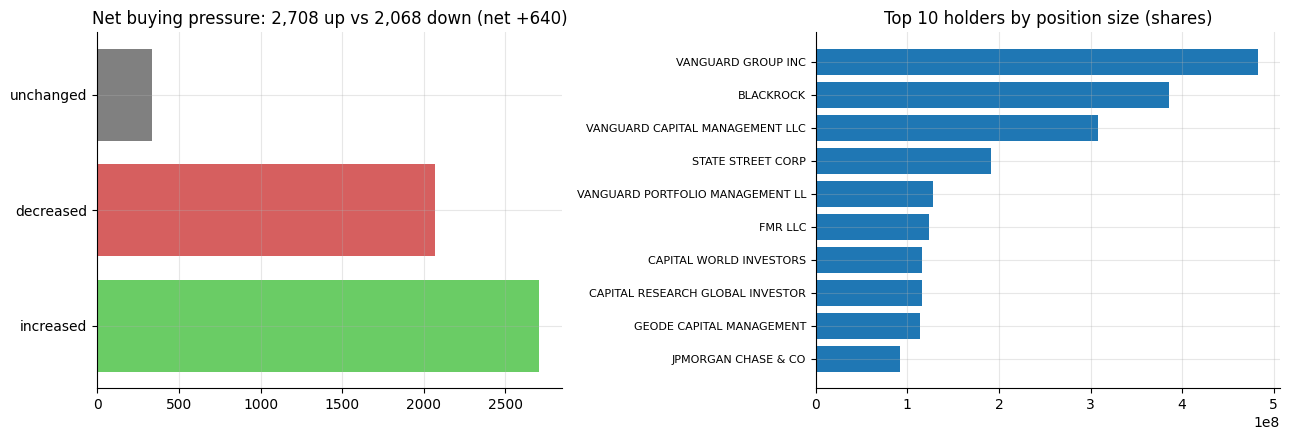

,holder_name,shares_held,shares_change,pct_of_portfolio,market_value
0,VANGUARD GROUP INC,"482,707,302",,%,$
1,BLACKROCK,"385,944,774",,%,$
2,VANGUARD CAPITAL MANAGEMENT LLC,"308,015,865",,%,$
3,STATE STREET CORP,"191,380,232",,%,$
4,VANGUARD PORTFOLIO MANAGEMENT LLC,"128,422,947",,%,$
5,FMR LLC,"124,112,876",,%,$
6,CAPITAL WORLD INVESTORS,"116,188,483",,%,$
7,CAPITAL RESEARCH GLOBAL INVESTORS,"116,025,298",,%,$
8,GEODE CAPITAL MANAGEMENT,"114,280,922",,%,$
9,JPMORGAN CHASE & CO,"91,782,808",,%,$


Concentration history (1 snapshot(s) so far — trends emerge as weekly pulls accumulate):


,pull_date,top10_pct_owned,top25_pct_owned,holder_count,holder_count_delta,total_shares_delta
0,2026-07-01,0.4950,0.6725,5096,<NA>,NaN


In [15]:
inst_sum = q(f"""
    SELECT * FROM {silver('dim_institutional_summary/*.parquet')}
    WHERE symbol = '{TICKER}'
    QUALIFY ROW_NUMBER() OVER (ORDER BY pull_date DESC) = 1
""")
holders = q(f"""
    SELECT holder_name, shares_held, shares_change, pct_of_portfolio, market_value
    FROM {silver('fact_institutional_holdings/*.parquet')}
    WHERE symbol = '{TICKER}'
      AND pull_date = (SELECT MAX(pull_date) FROM {silver('fact_institutional_holdings/*.parquet')}
                       WHERE symbol = '{TICKER}')
    ORDER BY COALESCE(market_value, shares_held) DESC
    LIMIT {TOP_HOLDERS_N}
""")

if inst_sum.empty:
    print(f"No institutional summary for {TICKER}.")
else:
    s = inst_sum.iloc[0]
    inc, dec, unch = (s.holders_with_increased_holdings, s.holders_with_decreased_holdings,
                      s.holders_with_unchanged_holdings)
    own = s.total_institutional_ownership_percentage
    own_txt = f"{own:.1f}%" if pd.notna(own) else "n/a"
    print(f"As of pull {pd.Timestamp(s.pull_date):%Y-%m-%d}: "
          f"{s.total_institutional_holders:,.0f} holders | institutional ownership {own_txt}")

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].barh(["increased", "decreased", "unchanged"], [inc, dec, unch],
                 color=["#6ACC65", "#D65F5F", "grey"])
    axes[0].set_title(f"Net buying pressure: {inc:,.0f} up vs {dec:,.0f} down "
                      f"(net {'+' if inc >= dec else ''}{inc - dec:,.0f})")
    top = holders.iloc[::-1]
    axes[1].barh(top.holder_name.str.slice(0, 32), top.shares_held, color="C0")
    axes[1].set_title(f"Top {TOP_HOLDERS_N} holders by position size (shares)")
    axes[1].tick_params(axis="y", labelsize=8)
    plt.tight_layout(); plt.show()
    display(holders.style.format({"shares_held": "{:,.0f}", "shares_change": "{:,.0f}",
                                  "market_value": "${:,.0f}", "pct_of_portfolio": "{:.2f}%"}))

conc = q(f"""
    SELECT pull_date, top10_pct_owned, top25_pct_owned, holder_count,
           holder_count_delta, total_shares_delta
    FROM {gold('fact_institutional_concentration/*.parquet')}
    WHERE symbol = '{TICKER}' ORDER BY pull_date
""")
print(f"Concentration history ({len(conc)} snapshot(s) so far — trends emerge as weekly pulls accumulate):")
conc

---
## 11. News sentiment trend

Rolling 30-day relevance-weighted `ticker_sentiment_score` from `gold/fact_sentiment_daily`,
with daily article counts, plus the most recent high-relevance headlines (static notebook —
a table stands in for hover tooltips).

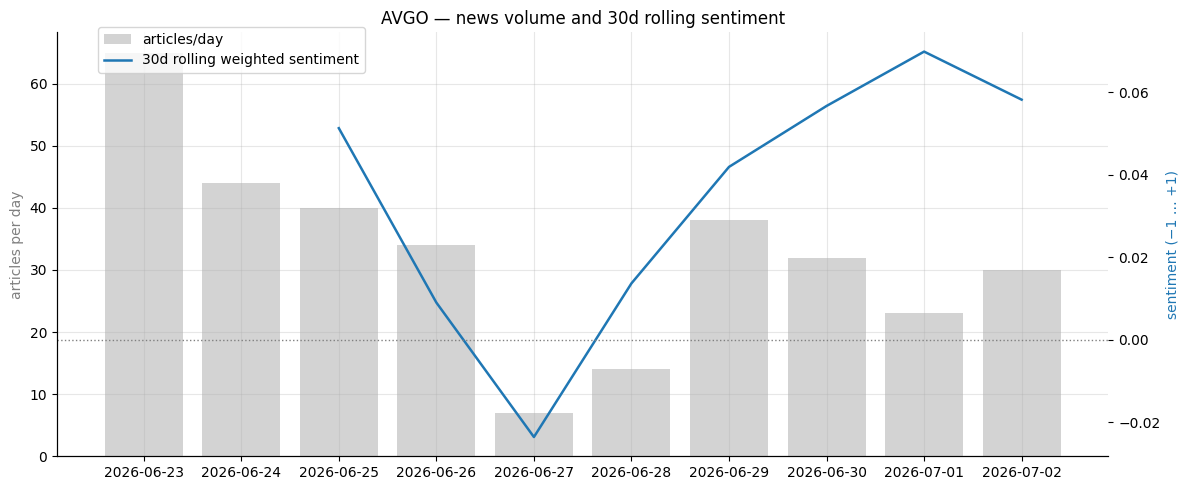

,time_published,title,source,relevance_score,ticker_sentiment_score,ticker_sentiment_label
0,2026-07-02 21:31:58,Form 4 Archer Daniels Midland For: 2 July By I...,Investing.com Canada,0.6127,-0.3464,Somewhat-Bearish
1,2026-07-02 21:10:48,Form 4 Black Stone Minerals For: 2 July By Inv...,Investing.com Canada,0.6364,-0.4873,Bearish
2,2026-07-02 21:10:35,Form 4 Bank of Hawaii Corp For: 2 July By Inve...,Investing.com Canada,0.6103,-0.3451,Somewhat-Bearish
3,2026-07-02 21:07:15,Form 4 Ambarella Inc For: 2 July By Investing.com,Investing.com Canada,0.6165,-0.5147,Bearish
4,2026-07-02 20:39:03,Form 4 Ares Management Corp Class A For: 2 Jul...,Investing.com Canada,0.6451,-0.1720,Somewhat-Bearish
5,2026-07-02 20:26:51,Form 4 Leidos Holdings Inc For: 2 July By Inve...,Investing.com Canada,0.6323,-0.4310,Bearish
6,2026-07-02 20:26:24,"Software's AI Death Knell Is a Hallucination, ...",Benzinga,0.6010,0.4297,Bullish
7,2026-07-02 20:16:30,Form 4 Sempra Energy For: 2 July By Investing.com,Investing.com Canada,0.5693,-0.6139,Bearish
8,2026-07-02 20:11:42,Form 4 Boston Scientific Corp For: 2 July By I...,Investing.com Canada,0.6093,0.1210,Neutral
9,2026-07-02 19:26:55,Everest Re Group stock hits 52-week high at 36...,Investing.com Canada,0.6025,-0.5026,Bearish


In [16]:
news = q(f"""
    SELECT sentiment_date, article_count, avg_sentiment_score, weighted_avg_sentiment,
           bullish_count, bearish_count
    FROM {gold('fact_sentiment_daily/**/*.parquet')}
    WHERE symbol = '{TICKER}'
    ORDER BY sentiment_date
""")

if news.empty:
    print(f"No news sentiment rows for {TICKER}.")
else:
    news["sentiment_date"] = pd.to_datetime(news.sentiment_date)
    news = news.set_index("sentiment_date").asfreq("D")
    news["article_count"] = news.article_count.fillna(0)
    roll = news.weighted_avg_sentiment.rolling(f"{NEWS_ROLL_DAYS}D", min_periods=3).mean()

    fig, ax = plt.subplots()
    ax.bar(news.index, news.article_count, color="lightgrey", label="articles/day")
    ax.set_ylabel("articles per day", color="grey")
    ax2 = ax.twinx()
    ax2.plot(roll.index, roll, color="C0", lw=1.8, label=f"{NEWS_ROLL_DAYS}d rolling weighted sentiment")
    ax2.axhline(0, color="grey", lw=1, ls=":")
    ax2.set_ylabel("sentiment (−1 … +1)", color="C0")
    ax2.grid(False)
    ax.set_title(f"{TICKER} — news volume and {NEWS_ROLL_DAYS}d rolling sentiment")
    fig.legend(loc="upper left", bbox_to_anchor=(0.08, 0.95))
    plt.tight_layout(); plt.show()

headlines = q(f"""
    SELECT a.time_published, a.title, a.source,
           t.relevance_score, t.ticker_sentiment_score, t.ticker_sentiment_label
    FROM {silver('fact_news_ticker_sentiment/*.parquet')} t
    JOIN {silver('fact_news_articles/*.parquet')} a USING (url)
    WHERE t.ticker = '{TICKER}' AND t.relevance_score >= {MIN_NEWS_RELEVANCE}
    ORDER BY a.time_published DESC
    LIMIT 15
""")
headlines

---
## Appendix — data dependencies & refresh cadence

Gold tables this notebook depends on, and when they refresh:

| Table | Builder | Cadence |
|---|---|---|
| `dim_company_enriched` | `build_dim_company_enriched` | weekly |
| `fact_fundamentals_wide` | `build_fundamentals_wide` | weekly |
| `fact_insider_signals` | `build_insider_signals` | weekly |
| `fact_institutional_concentration` | `build_institutional_concentration` | weekly |
| `fact_sentiment_daily` | `build_news_sentiment_daily` | daily |
| `fact_transcript_sentiment` | `build_transcript_sentiment` *(new)* | weekly |
| `dim_peer_sets` | `build_peer_sets` *(new)* | weekly |

Everything else reads silver directly (`fact_daily_prices`, `fact_splits`, `fact_dividends`,
`fact_earnings`, `fact_insider_transactions`, `fact_institutional_*`, `fact_news_*`).

**Known gaps (as of 2026-07):**
- Transcript history: ~1 quarter/symbol until `transcripts_backfill.yml` finishes; section 8
  deepens automatically afterward.
- Institutional data: single pull so far; section 10's trend view fills in as weekly
  snapshots accumulate.
- Insider coverage: ~340 of ~1,590 symbols have Form 4 rows.